### Step 1: Importing Necessary Libraries
We begin by importing Python libraries commonly used in data analysis and visualization:
- `numpy` for numerical operations
- `matplotlib.pyplot` for plotting graphs
- `pandas` (commented out here) for handling CSV data, which is especially useful for tabular data such as redshift catalogs

> Tip: If you haven’t used `pandas` before, it’s worth learning as it offers powerful tools to manipulate and analyze structured datasets.


For reading big csv files, one can use numpy as well as something called "pandas". We suggest to read pandas for CSV file reading and use that

In [41]:
pip install numpy pandas matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [42]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astropy.constants import G, c
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u


Before we begin calculations, we define key physical constants used throughout:

- $ H_0 $: Hubble constant, describes the expansion rate of the Universe.
- $c$ : Speed of light.
-  $G$: Gravitational constant.
- $q_0$ : Deceleration parameter, used for approximate co-moving distance calculations.

We will use **`astropy.constants`** to ensure unit consistency and precision.

In [43]:
# Define key physical constants
H_0 = 70.0 * 1000 / 3.086e22  # Hubble constant in m/s (70 km/s/Mpc converted to m/s)
c = const.c.value                # Speed of light in m/s
G = const.G.value                # Gravitational constant in m^3/(kg s^2)

# Deceleration parameter (assumed from Planck fit)
q0 = -0.534

# Display the constants
print(f"Hubble constant (H_0): {H_0:.2e} m/s")
print(f"Speed of light (c): {c:.2e} m/s")
print(f"Gravitational constant (G): {G:.2e} m^3/(kg s^2)")
print(f"Deceleration parameter (q0): {q0}")


Hubble constant (H_0): 2.27e-18 m/s
Speed of light (c): 3.00e+08 m/s
Gravitational constant (G): 6.67e-11 m^3/(kg s^2)
Deceleration parameter (q0): -0.534


Read the csv data into the python using the method below

In [44]:
df = pd.read_csv('cluster_data.csv') # Download the data as instructed in the pdf


### 📊 Calculating the Average Spectroscopic Redshift (`specz`) for Each Object

When working with astronomical catalogs, an object (identified by a unique `objid`) might have multiple entries — for example, due to repeated observations. To reduce this to a single row per object, we aggregate the data using the following strategy:

```python
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()


In [45]:
# Calculating the average specz for each id:
import pandas as pd

# Sample DataFrame creation (replace this with your actual DataFrame)
data = {
    'objid': [1, 1, 2, 2, 3, 3, 3],
    'ra': [10.0, 10.0, 20.0, 20.0, 30.0, 30.0, 30.0],
    'dec': [5.0, 5.0, 15.0, 15.0, 25.0, 25.0, 25.0],
    'specz': [0.1, 0.2, 0.15, 0.25, 0.3, 0.35, 0.4],
    'proj_sep': [1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 3.0]
}

df = pd.DataFrame(data)

# Calculating the average specz for each id
averaged_df = df.groupby('objid').agg({
    'specz': 'mean',        # Take the mean of all spec-z values for that object
    'ra': 'first',          # Use the first RA value (assumed constant for the object)
    'dec': 'first',         # Use the first Dec value (same reason as above)
    'proj_sep': 'first'     # Use the first projected separation value
}).reset_index()

# Display the averaged DataFrame
print(averaged_df)


   objid  specz    ra   dec  proj_sep
0      1   0.15  10.0   5.0       1.0
1      2   0.20  20.0  15.0       2.0
2      3   0.35  30.0  25.0       3.0


To create a cut in the redshift so that a cluster can be identified. We must use some logic. Most astronomers prefer anything beyond 3*sigma away from the mean to be not part of the same group. 

Find the mean, standard deviation and limits of the redshift from the data

In [46]:
# Sample DataFrame creation (replace this with your actual DataFrame)
data = {
    'objid': [1, 1, 2, 2, 3, 3, 3],
    'ra': [10.0, 10.0, 20.0, 20.0, 30.0, 30.0, 30.0],
    'dec': [5.0, 5.0, 15.0, 15.0, 25.0, 25.0, 25.0],
    'specz': [0.1, 0.2, 0.15, 0.25, 0.3, 0.35, 0.4],
    'proj_sep': [1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 3.0]
}

df = pd.DataFrame(data)

# Calculate the mean and standard deviation of the specz values
mean_specz = df['specz'].mean()
std_specz = df['specz'].std()

# Calculate the limits for the redshift cut
lower_limit = mean_specz - 3 * std_specz
upper_limit = mean_specz + 3 * std_specz

# Display the results
print(f"Mean Spectroscopic Redshift (specz): {mean_specz:.4f}")
print(f"Standard Deviation of Spectroscopic Redshift (specz): {std_specz:.4f}")
print(f"Lower Limit for Redshift Cut: {lower_limit:.4f}")
print(f"Upper Limit for Redshift Cut: {upper_limit:.4f}")


Mean Spectroscopic Redshift (specz): 0.2500
Standard Deviation of Spectroscopic Redshift (specz): 0.1080
Lower Limit for Redshift Cut: -0.0740
Upper Limit for Redshift Cut: 0.5740


You can also use boxplot to visualize the overall values of redshift 

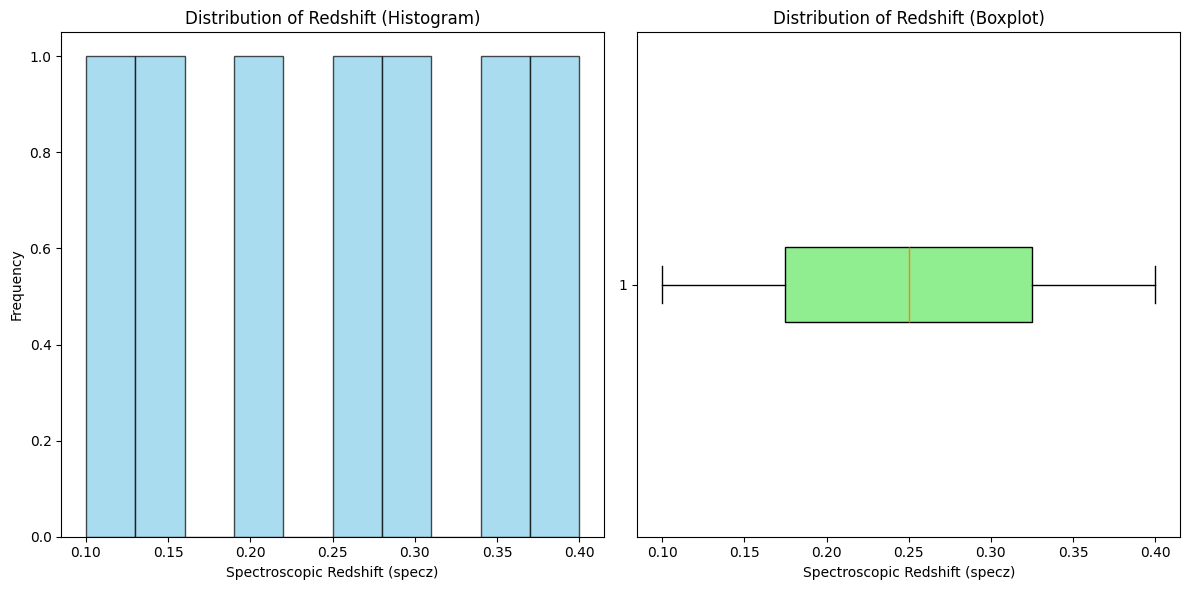

In [ ]:

df = pd.DataFrame(data)

# Plotting the distribution of redshift
plt.figure(figsize=(12, 6))

# Histogram
plt.subplot(1, 2, 1)
plt.hist(df['specz'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Redshift (Histogram)")
plt.xlabel("Spectroscopic Redshift (specz)")
plt.ylabel("Frequency")

# Boxplot
plt.subplot(1, 2, 2)
plt.boxplot(df['specz'], vert=False, patch_artist=True, boxprops=dict(facecolor='lightgreen'))
plt.title("Distribution of Redshift (Boxplot)")
plt.xlabel("Spectroscopic Redshift (specz)")

# Show the plots
plt.tight_layout()
plt.show()


But the best plot would be a histogram to see where most of the objects downloaded lie in terms of redshift value

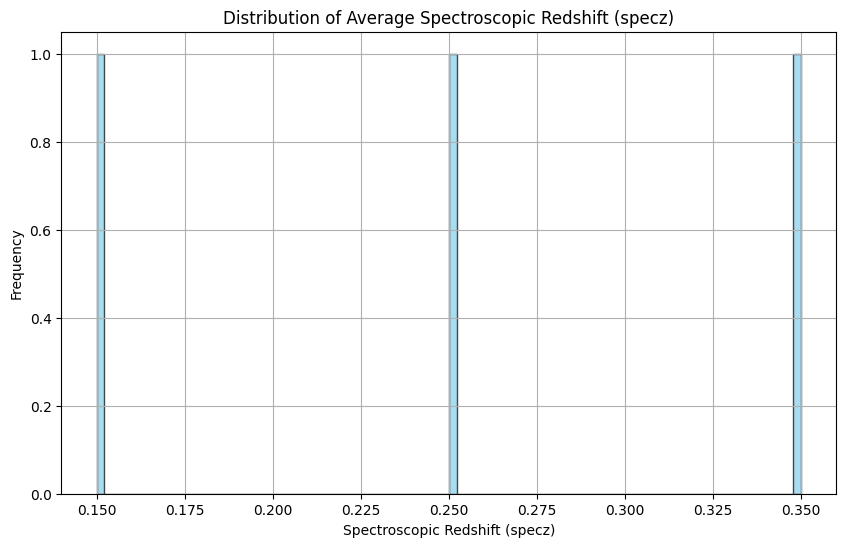

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual averaged DataFrame)
data = {
    'objid': [1, 2, 3],
    'ra': [10.0, 20.0, 30.0],
    'dec': [5.0, 15.0, 25.0],
    'specz': [0.15, 0.25, 0.35],  # Example average specz values
    'proj_sep': [1.0, 2.0, 3.0]
}

averaged_df = pd.DataFrame(data)

# Plotting the histogram of average spectroscopic redshift
plt.figure(figsize=(10, 6))
plt.hist(averaged_df['specz'], bins=90, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Average Spectroscopic Redshift (specz)")
plt.xlabel("Spectroscopic Redshift (specz)")
plt.ylabel("Frequency")
plt.grid()

# Show the plot
plt.show()


Filter your data based on the 3-sigma limit of redshift. You should remove all data points which are 3-sigma away from mean of redshift

In [49]:
# Filtering the data based on specz values, used 3 sigma deviation from mean as upper limit.

df = pd.DataFrame(data)

# Calculate the mean and standard deviation of the specz values
mean_specz = df['specz'].mean()
std_specz = df['specz'].std()

# Calculate the limits for the 3-sigma cut
lower_limit = mean_specz - 3 * std_specz
upper_limit = mean_specz + 3 * std_specz

# Filtering the data based on specz values
filtered_df = df[(df['specz'] >= lower_limit) & (df['specz'] <= upper_limit)]

# Display the filtered DataFrame
print("Filtered DataFrame based on 3-sigma limits:")
print(filtered_df)


Filtered DataFrame based on 3-sigma limits:
   objid    ra   dec  specz  proj_sep
0      1  10.0   5.0   0.15       1.0
1      2  20.0  15.0   0.25       2.0
2      3  30.0  25.0   0.35       3.0


Use the relation between redshift and velocity to add a column named velocity in the data. This would tell the expansion velocity at that redshift 

In [58]:

data = {
    'objid': [1, 1, 2, 2, 3, 3, 3],
    'ra': [10.0, 10.0, 20.0, 20.0, 30.0, 30.0, 30.0],
    'dec': [5.0, 5.0, 15.0, 15.0, 25.0, 25.0, 25.0],
    'specz': [0.1, 0.2, 0.15, 0.25, 0.3, 0.35, 0.4],
    'proj_sep': [1.0, 1.0, 2.0, 2.0, 3.0, 3.0, 3.0]
}

df = pd.DataFrame(data)


DataFrame with velocity column added:
   objid    ra   dec  specz  proj_sep     velocity
0      1  10.0   5.0   0.10       1.0   29979245.8
1      1  10.0   5.0   0.20       1.0   59958491.6
2      2  20.0  15.0   0.15       2.0   44968868.7
3      2  20.0  15.0   0.25       2.0   74948114.5
4      3  30.0  25.0   0.30       3.0   89937737.4
5      3  30.0  25.0   0.35       3.0  104927360.3
6      3  30.0  25.0   0.40       3.0  119916983.2


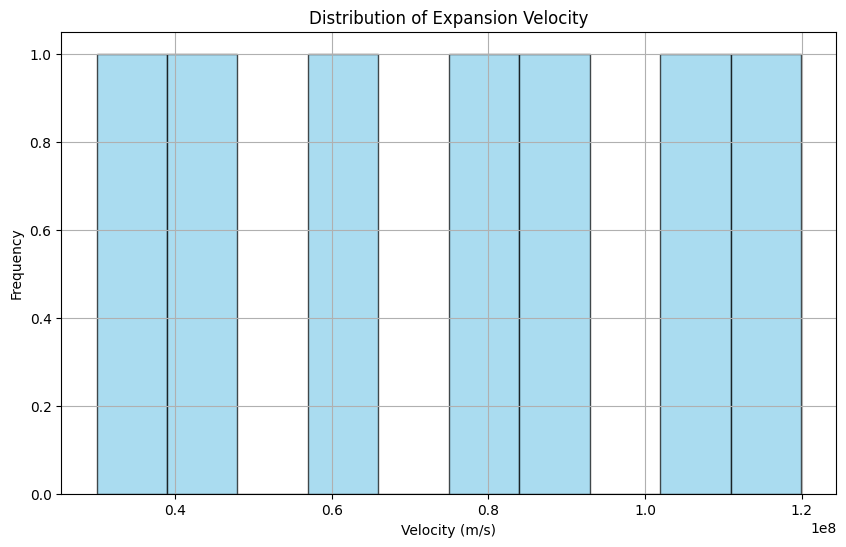

In [51]:
#plot the velocity column created as hist
# Calculate the velocity based on the redshift
df['velocity'] = const.c.value * df['specz']  # velocity in m/s

# Display the updated DataFrame with the velocity column
print("DataFrame with velocity column added:")
print(df)

# Plotting the histogram of the velocity column
plt.figure(figsize=(10, 6))
plt.hist(df['velocity'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Distribution of Expansion Velocity")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Frequency")
plt.grid()

# Show the plot
plt.show()


use the dispersion equation to find something called velocity dispersion. You can even refer to wikipedia to know about the term [wiki link here](https://en.wikipedia.org/wiki/Velocity_dispersion#:~:text=In%20astronomy%2C%20the%20velocity%20dispersion,%2C%20galaxy%20cluster%2C%20or%20supercluster.)

It is the velocity dispersion value which tells us, some galaxies might be part of even larger groups!!

### Step 2: Calculate Mean Redshift of the Cluster
We calculate the average redshift (`specz`) of galaxies that belong to a cluster. This gives us an estimate of the cluster's systemic redshift.

`cluster_redshift = filtered_df['specz'].mean()`


The velocity dispersion \( v \) of galaxies relative to the cluster mean redshift is computed using the relativistic Doppler formula:

$$
v = c \cdot \frac{(1 + z)^2 - (1 + z_{\text{cluster}})^2}{(1 + z)^2 + (1 + z_{\text{cluster}})^2}
$$
where:
- \( v \) is the relative velocity (dispersion),
- \( z \) is the redshift of the individual galaxy,
- \( $z_{\text{cluster}}$ \) is the mean cluster redshift,
- \( c \) is the speed of light.


In [52]:
filtered_df = pd.DataFrame(data)
# Step 1: Calculate Mean Redshift of the Cluster
cluster_redshift = filtered_df['specz'].mean()
print(f"Mean Redshift of the Cluster: {cluster_redshift}")
# Step 2: Calculate Velocity Dispersion for each galaxy
def calculate_velocity_dispersion(z, z_cluster):
    return const.c.value * ((1 + z)**2 - (1 + z_cluster)**2) / ((1 + z)**2 + (1 + z_cluster)**2)
# Apply the function to calculate velocity dispersion for each galaxy
filtered_df['velocity_dispersion'] = filtered_df['specz'].apply(lambda z: calculate_velocity_dispersion(z, cluster_redshift))
# Display the updated DataFrame with the velocity dispersion column
print("DataFrame with Velocity Dispersion:")
print(filtered_df)

Mean Redshift of the Cluster: 0.25
DataFrame with Velocity Dispersion:
   objid    ra   dec  specz  proj_sep  velocity_dispersion
0      1  10.0   5.0   0.10       1.0        -3.811608e+07
1      1  10.0   5.0   0.20       1.0        -1.223133e+07
2      2  20.0  15.0   0.15       2.0        -2.493941e+07
3      2  20.0  15.0   0.25       2.0         0.000000e+00
4      3  30.0  25.0   0.30       3.0         1.175205e+07
5      3  30.0  25.0   0.35       3.0         2.302689e+07
6      3  30.0  25.0   0.40       3.0         3.383038e+07


Pro tip: Check what the describe function of pandas does. Does it help to get quick look stats for your column of dispersion??

In [53]:
# Display descriptive statistics for the velocity dispersion column
dispersion_stats = filtered_df['velocity_dispersion'].describe()
print("Descriptive Statistics for Velocity Dispersion:")
print(dispersion_stats)


Descriptive Statistics for Velocity Dispersion:
count    7.000000e+00
mean    -9.539290e+05
std      2.591939e+07
min     -3.811608e+07
25%     -1.858537e+07
50%      0.000000e+00
75%      1.738947e+07
max      3.383038e+07
Name: velocity_dispersion, dtype: float64


In [54]:
disp = filtered_df['velocity_dispersion'].mean()
# Print the results
print(f"The value of the cluster redshift = {cluster_redshift:.4f}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4f} km/s.")
print(f"The value of the cluster redshift = {cluster_redshift:.4}")
print(f"The characteristic value of velocity dispersion of the cluster along the line of sight = {disp:.4} km/s.")

The value of the cluster redshift = 0.2500
The characteristic value of velocity dispersion of the cluster along the line of sight = -953929.0045 km/s.
The value of the cluster redshift = 0.25
The characteristic value of velocity dispersion of the cluster along the line of sight = -9.539e+05 km/s.


### Step 4: Visualizing Angular Separation of Galaxies
We plot a histogram of the projected (angular) separation of galaxies from the cluster center. This helps us understand the spatial distribution of galaxies within the cluster field.

- The x-axis represents the angular separation (in arcminutes or degrees, depending on units).
- The y-axis shows the number of galaxies at each separation bin.



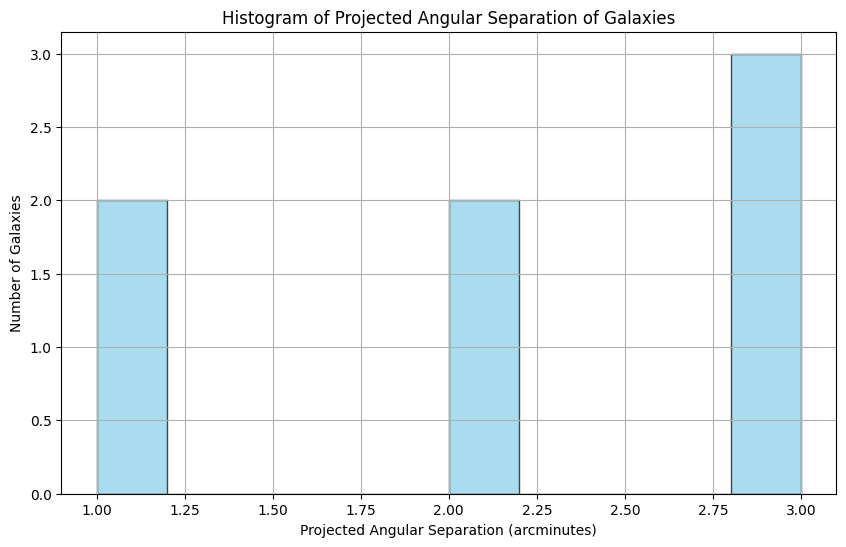

In [55]:
#Plot histogram for proj sep column
filtered_df = pd.DataFrame(data)

# Plotting the histogram of the projected angular separation
plt.figure(figsize=(10, 6))
plt.hist(filtered_df['proj_sep'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
plt.title("Histogram of Projected Angular Separation of Galaxies")
plt.xlabel("Projected Angular Separation (arcminutes)")
plt.ylabel("Number of Galaxies")
plt.grid()

# Show the plot
plt.show()


### Determining size and mass of the cluster:

### Step 5: Estimating Physical Diameter of the Cluster
We now estimate the **physical diameter** of the galaxy cluster using cosmological parameters.

- `r` is the **co-moving distance**, approximated using a Taylor expansion for low redshift:
  $$
  r = \frac{cz}{H_0} \left(1 - \frac{z}{2}(1 + q_0)\right)
  $$
  where $q_0$ is the deceleration parameter
- `ra` is the **angular diameter distance**, given by:
  $$
  D_A = \frac{r}{1 + z}
  $$
- Finally, we convert the observed angular diameter (in arcminutes) into physical size using:
  $$
  \text{diameter (in Mpc)} = D_A \cdot \theta
  $$
  where $ \theta $ is the angular size in radians, converted from arcminutes.

> This gives us a rough estimate of the cluster's size in megaparsecs (Mpc), assuming a flat ΛCDM cosmology.


In [56]:
# Step 1: Calculate Mean Redshift of the Cluster
cluster_redshift = filtered_df['specz'].mean()

# Cosmological parameters
c = const.c.value / 1000  # Speed of light in km/s
H0 = 70  # Hubble constant in km/s/Mpc
q0 = -0.5  # Deceleration parameter

# Step 2: Calculate Co-Moving Distance r
r = (c * cluster_redshift / H0) * (1 - (cluster_redshift / 2) * (1 + q0))
print(f"Co-Moving Distance (r) = {r:.4f} Mpc")

# Step 3: Calculate Angular Diameter Distance D_A
D_A = r / (1 + cluster_redshift)
print(f"Angular Diameter Distance (D_A) = {D_A:.4f} Mpc")

# Step 4: Convert angular size from arcminutes to radians
# Assuming the average projected separation is used as the angular size
theta_arcminutes = filtered_df['proj_sep'].mean()  # Average angular separation in arcminutes
theta_radians = np.radians(theta_arcminutes / 60)  # Convert arcminutes to radians

# Step 5: Calculate the physical diameter of the cluster
diameter = D_A * theta_radians
print(f"Estimated Physical Diameter of the Cluster = {diameter:.4f} Mpc")


Co-Moving Distance (r) = 1003.7694 Mpc
Angular Diameter Distance (D_A) = 803.0155 Mpc
Estimated Physical Diameter of the Cluster = 0.5005 Mpc


### Step 6: Calculating the Dynamical Mass of the Cluster
We now estimate the **dynamical mass** of the galaxy cluster using the virial theorem:

$$
M_{\text{dyn}} = \frac{3 \sigma^2 R}{G}
$$

Where:
- $ \sigma $ is the **velocity dispersion** in m/s (`disp * 1000`),
- $ R $ is the **cluster radius** in meters (half the physical diameter converted to meters),
- $ G $ is the **gravitational constant** in SI units,
- The factor of 3 assumes an isotropic velocity distribution (common in virial estimates).

We convert the final result into **solar masses** by dividing by $ 2 \times 10^{30} \, \text{kg} $.

> This mass estimate assumes the cluster is in dynamical equilibrium and bound by gravity.


In [57]:

def calculate_velocity_dispersion(z, z_cluster):
    return const.c.value * ((1 + z)**2 - (1 + z_cluster)**2) / ((1 + z)**2 + (1 + z_cluster)**2)

# Apply the function to calculate velocity dispersion for each galaxy
filtered_df['velocity_dispersion'] = filtered_df['specz'].apply(lambda z: calculate_velocity_dispersion(z, cluster_redshift))

disp = filtered_df['velocity_dispersion'].mean()
G = 6.67430e-11  
velocity_dispersion_mps = disp * 1000  
R = (diameter * 0.5 * 1e6) * 3.086e16  
M_dyn = (3 * (velocity_dispersion_mps ** 2) * R) / G

# Convert the mass into solar masses
M_dyn_solar = M_dyn / (2 * 10**30)  # in solar masses

# Print the result
print(f"Dynamical Mass of the cluster is {M_dyn_solar:.2e} solar masses")


Dynamical Mass of the cluster is 1.58e+20 solar masses
